In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from src.models import SIRM, SIRT, SIRV
from helps import *




from src.utils.batch_sweep import sweep_two_parameters

# Import the matrix creation function
from src.utils.Contact_Matrix import create_contact_matrix
from copy import deepcopy



NB = 30
NP = 30
homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
simulated_days = 3000

default_0_hom = 0
default_0_pol = 0.001

In [2]:
def run_one(R0, PARAMS, spec, model, pol_baseline, hom_baseline, simulated_days = 3000, sampling_points = 2):
    CB = deepcopy(PARAMS)
    
    pols = [spec["pol"][0], spec["pol"][2]]
    homs = [spec["h"][0], spec["h"][2]]


    CB["beta_M"] = R0 * CB["recovery_rate"]
    CB["fixed_mean"] = spec["mean"][1]
    # run the heterogeneous simulation
    RES_HET = sweep_two_parameters(
        model_module=model,
        param1_name="beta_params",              # parameter 1 name
        param1_range=pols,                      # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homs,                      # parameter 2 range
        custom_base_params=CB,
        simulated_days=simulated_days,
        population_size=5,
        batch_size= 4
    )
    # run the homogeneous simulation
    RES_HOM = sweep_two_parameters(
        model_module=model,
        param1_name="beta_params",              # parameter 1 name
        param1_range=pol_baseline,              # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=hom_baseline,              # parameter 2 range
        custom_base_params=CB,
        simulated_days=simulated_days,
        population_size=5,
        batch_size=1
    )
    HET = np.sum(RES_HET["final_state"]["R"], axis=2) + np.sum(RES_HET["final_state"]["I"], axis=2)
    HOM = np.sum(RES_HOM["final_state"]["R"], axis=2) + np.sum(RES_HOM["final_state"]["I"], axis=2)
    return HET, HOM

In [ ]:
def calc_minmax_trajectories(model, min_hom_pol, max_hom_pol, mean, PARAMS, default_0_pol, default_0_hom, simulated_days=1000):

    _ , I_min, R_min, *_ = run_single_simulation(min_hom_pol[0], min_hom_pol[1], mean, PARAMS, model, simulated_days=simulated_days)
    _ , I_max, R_max, *_ = run_single_simulation(max_hom_pol[0], max_hom_pol[1], mean, PARAMS, model, simulated_days=simulated_days)
    _ , I_base, R_base, *_ = run_single_simulation(default_0_pol, default_0_hom, mean, PARAMS, model, simulated_days=simulated_days)
    
    return I_min + R_min, I_max + R_max, I_base + R_base

In [ ]:
from copy import deepcopy

def run_one(R0, PARAMS, spec, model, pol_baseline, hom_baseline, simulated_days = 3000, sampling_points = 2):
    CB = deepcopy(PARAMS)
    
    pols = {"m": spec["pol"][0], "M": spec["pol"][2], "n": sampling_points}
    homs = {"m": spec["h"][0], "M": spec["h"][2], "n": sampling_points}


    CB["beta_M"] = R0 * CB["recovery_rate"]
    CB["fixed_mean"] = spec["mean"][1]
    # run the heterogeneous simulation
    RES_HET = sweep_two_parameters(
        model_module=model,
        param1_name="beta_params",              # parameter 1 name
        param1_range=pols,                      # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homs,                      # parameter 2 range
        custom_base_params=CB,
        simulated_days=simulated_days,
        population_size=5,
        batch_size= sampling_points*sampling_points
    )
    # run the homogeneous simulation
    RES_HOM = sweep_two_parameters(
        model_module=model,
        param1_name="beta_params",              # parameter 1 name
        param1_range=pol_baseline,              # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=hom_baseline,              # parameter 2 range
        custom_base_params=CB,
        simulated_days=simulated_days,
        population_size=5,
        batch_size=1
    )
    HET = np.sum(RES_HET["final_state"]["R"], axis=2) + np.sum(RES_HET["final_state"]["I"], axis=2)
    HOM = np.sum(RES_HOM["final_state"]["R"], axis=2) + np.sum(RES_HOM["final_state"]["I"], axis=2)
    return HET, HOM

def plot_three_extra_cases_ranges(SIRM_stuff, SIRT_stuff, SIRV_stuff, R0s):
    [sirm_min_main, sirm_max_main, sirm_hom_main] = SIRM_stuff
    [sirt_min_main, sirt_max_main, sirt_hom_main] = SIRT_stuff
    [sirv_min_main, sirv_max_main, sirv_hom_main] = SIRV_stuff
    

    fig, axs = plt.subplots(1, 1, figsize=(3, 2))

    M_min_main = (sirm_min_main - sirm_hom_main)*100
    M_max_main = (sirm_max_main - sirm_hom_main)*100

    T_min_main = (sirt_min_main - sirt_hom_main)*100
    T_max_main = (sirt_max_main - sirt_hom_main)*100

    V_min_main = (sirv_min_main - sirv_hom_main)*100
    V_max_main = (sirv_max_main - sirv_hom_main)*100

    LW = 0.5

    colors_3 = ["#7570b3", "#d95f02", "#1b9e77"]

    axs.fill_between(R0s, M_min_main, M_max_main, color=colors_3[0], alpha=1)
    axs.plot(R0s, M_min_main, label="SIR-M min", color='black', linewidth=LW)
    axs.plot(R0s, M_max_main, label="SIR-M max", color='black', linewidth=LW)


    axs.fill_between(R0s, T_min_main, T_max_main, color=colors_3[1], alpha=1)
    axs.plot(R0s, T_min_main, label="SIR-T min", color='black', linewidth=LW)
    axs.plot(R0s, T_max_main, label="SIR-T max", color='black', linewidth=LW)



    axs.axhline(0, color='black', linestyle='--', linewidth=1)
    axs.fill_between(R0s, V_min_main, V_max_main, color=colors_3[2], alpha=1)
    axs.plot(R0s, V_min_main, label="SIR-V min", color='black', linewidth=LW)
    axs.plot(R0s, V_max_main, label="SIR-V max", color='black', linewidth=LW)



    axs.axvline(2.5, color='black', linestyle=':', linewidth=1)
    axs.axvline(2.75, color='black', linestyle=':', linewidth=1)
    axs.axvline(3, color='black', linestyle=':', linewidth=1)

    axs.set_ylim(-50, 50)
    axs.set_xlim(1, 5)

    axs.set_xticks([1, 3, 5])
    axs.set_yticks([-50, 0, 50])

    axs.set_xticklabels([])
    axs.set_yticklabels([])

    # remove top and right spines
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)












    # find the maximum percentage increase across all R0s for each model, at what value of R0 does it occur?
    max_increase_M = np.max(M_max_main)
    max_increase_T = np.max(T_max_main)
    max_increase_V = np.max(V_max_main)

    maxR0_M = R0s[np.argmax(M_max_main)]
    maxR0_T = R0s[np.argmax(T_max_main)]
    maxR0_V = R0s[np.argmax(V_max_main)]

    # same but for the minimum percentage increase
    min_increase_M = np.min(M_min_main)
    min_increase_T = np.min(T_min_main)
    min_increase_V = np.min(V_min_main)

    minR0_M = R0s[np.argmin(M_min_main)]
    minR0_T = R0s[np.argmin(T_min_main)]
    minR0_V = R0s[np.argmin(V_min_main)]

    print(f"Maximum percentage increase for SIR-M: {max_increase_M:.2f}% at R0 = {maxR0_M:.2f}")
    print(f"Maximum percentage increase for SIR-T: {max_increase_T:.2f}% at R0 = {maxR0_T:.2f}")
    print(f"Maximum percentage increase for SIR-V: {max_increase_V:.2f}% at R0 = {maxR0_V:.2f}")
    print("_________")

    print(f"Minimum percentage increase for SIR-M: {min_increase_M:.2f}% at R0 = {minR0_M:.2f}")
    print(f"Minimum percentage increase for SIR-T: {min_increase_T:.2f}% at R0 = {minR0_T:.2f}")
    print(f"Minimum percentage increase for SIR-V: {min_increase_V:.2f}% at R0 = {minR0_V:.2f}")













    #fig.savefig("figures/Fig_4/percentage_increase.pdf", dpi=300, bbox_inches='tight')

In [24]:
def run_one(R0, PARAMS, spec, model, pol_baseline, hom_baseline, simulated_days = 3000, sampling_points = 2, flag = False):
    CB = deepcopy(PARAMS)
    
    pols = {"m": spec["pol"][0], "M": spec["pol"][2], "n": sampling_points}
    homs = {"m": spec["h"][0], "M": spec["h"][2], "n": sampling_points}

    CB["beta_M"] = R0 * CB["recovery_rate"]
    CB["fixed_mean"] = spec["mean"][1]
    # run the heterogeneous simulation
    RES_HET = sweep_two_parameters(
        model_module=model,
        param1_name="beta_params",
        param1_range=pols,
        param2_name="homophilic_tendency",
        param2_range=homs,
        custom_base_params=CB,
        simulated_days=simulated_days,
        population_size=5,
        batch_size= sampling_points*sampling_points
    )
    # run the homogeneous simulation
    RES_HOM = sweep_two_parameters(
        model_module=model,
        param1_name="beta_params",
        param1_range=pol_baseline,
        param2_name="homophilic_tendency",
        param2_range=hom_baseline,
        custom_base_params=CB,
        simulated_days=simulated_days,
        population_size=5,
        batch_size=1
    )
    HET = np.sum(RES_HET["final_state"]["R"], axis=2) + np.sum(RES_HET["final_state"]["I"], axis=2)
    HOM = np.sum(RES_HOM["final_state"]["R"], axis=2) + np.sum(RES_HOM["final_state"]["I"], axis=2)

    if flag == True:
        Het_history = run_trajectories(model, CB, pols, homs, simulated_days)
        Hom_history = run_trajectories(model, CB, pol_baseline, hom_baseline, simulated_days)
    else:
        Het_history = [0]
        Hom_history = [0]
    return HET, HOM, Het_history, Hom_history

from src.utils.distributions import pol_mean_to_ab, homogeneous_distribution
import jax.numpy as jnp

def run_trajectories(model, base_params, param1_range, param2_range, simulated_days):
    pol_vals = process_range(param1_range)
    hom_vals = process_range(param2_range)
    
    trajectories = []
    for pol in pol_vals:
        row = []
        for hom in hom_vals:
            
            a, b = pol_mean_to_ab(pol, base_params["fixed_mean"])
            params = dict(base_params)
            params["homophilic_tendency"] = hom
            states, _, _ = model.run_simulation(
                beta_params=(a, b),
                params=params,
                simulated_days=simulated_days,
                population_size=5,
                return_trajectory=True
            )
            row.append(states)
        trajectories.append(row)
    return trajectories


def process_range(param_range):
    if isinstance(param_range, dict):
        return homogeneous_distribution(param_range["n"], param_range["m"], param_range["M"])
    return jnp.array(param_range)

In [3]:
temp = read_json("./parameters.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]
rect_coords_M = [mus["pol"][0], mus["h"][0], mus["pol"][2]-mus["pol"][0], mus["h"][2]-mus["h"][0]]
rect_coords_T = [taus["pol"][0], taus["h"][0], taus["pol"][2]-taus["pol"][0], taus["h"][2]-taus["h"][0]]
rect_coords_V = [xis["pol"][0], xis["h"][0], xis["pol"][2]-xis["pol"][0], xis["h"][2]-xis["h"][0]]







PARAMS["fixed_mean"] = 0.5
# visualization parameters

colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.2, 0.4, 0.5, 0.6, 0.8]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx/1.25,  # Figure width in inches
        'Ly': Ly/1.25,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 3, 6],
        'xlim': [0, 1],
        'ylim': [0, 6]
    }

In [4]:
Three_betas = [0.15, 0.25, 0.45]

In [5]:
from bootstrap_CM_module import *
df = pd.read_csv("data_homophily.csv")
df = df.dropna()

mask_distribution = extract_behavior_distribution_vectorized(df, "masks")
test_distribution = extract_behavior_distribution_vectorized(df, "testing")
vaccine_distribution = extract_behavior_distribution_vectorized(df, "vacc")

mask_matrix = generate_contact_matrix(df, "masks")
test_matrix = generate_contact_matrix(df, "testing")
vaccine_matrix = generate_contact_matrix(df, "vacc")

In [6]:
# calculate and print the range of the confidence interval:
R_M = bootstrap_mph(df, "masks", n_bootstrap=2000)
R_T = bootstrap_mph(df, "testing", n_bootstrap=2000)
R_V = bootstrap_mph(df, "vacc", n_bootstrap=2000)

print(f"[{np.round(R_M['M_CI'], 2)}, {np.round(R_M['P_CI'], 2)}, {np.round(R_M['H_CI'], 2)}]")
print(f"[{np.round(R_T['M_CI'], 2)}, {np.round(R_T['P_CI'], 2)}, {np.round(R_T['H_CI'], 2)}]")
print(f"[{np.round(R_V['M_CI'], 2)}, {np.round(R_V['P_CI'], 2)}, {np.round(R_V['H_CI'], 2)}]")

Bootstrapping MPH for vacc: 100%|██████████| 2000/2000 [00:01<00:00, 1350.91it/s]

[[0.76 0.77 0.79], [0.25 0.28 0.3 ], [1.77 2.59 3.34]]
[[0.45 0.47 0.49], [0.46 0.48 0.5 ], [1.97 2.28 2.57]]
[[0.59 0.61 0.63], [0.55 0.57 0.6 ], [1.35 1.72 2.11]]


In [7]:
betas = [0.25]
print(homophilic_tendency)
print(pol_range)
print("### SIR-M ###")
PS = 5
res_list_M = []
PARAMS["fixed_mean"] = mus["mean"][1]
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=simulated_days,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")


print("### SIR-T ###")
res_list_T = []
PARAMS["fixed_mean"] = taus["mean"][1]
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=simulated_days,
        population_size=PS,
        batch_size=2000
    )
    res_list_T.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-V ###")
res_list_V = []
PARAMS["fixed_mean"] = xis["mean"][1]
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=simulated_days,
        population_size=PS,
        batch_size=2000
    )
    res_list_V.append(M)
    print(f"Completed beta_M = {b}")

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


{'m': 0, 'M': 6, 'n': 30}
{'m': 0, 'M': 1, 'n': 30}
### SIR-M ###
Completed beta_M = 0.25
### SIR-T ###
Completed beta_M = 0.25
### SIR-V ###
Completed beta_M = 0.25


min-max range: 1.4901161e-05  to  0.20406109  -- max variation --  20.0
min-max range: 0.40077204  to  0.7240858  -- max variation --  32.0
min-max range: 0.07436895  to  0.3818292  -- max variation --  31.0


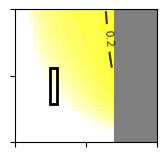

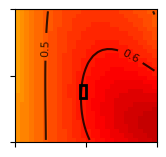

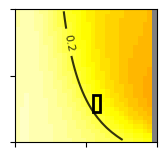

In [10]:
fig_R_M_1_H = plot_multiple_metrics(
    res_list_M[0], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_M
)
fig_R_M_1_H = plot_multiple_metrics(
    res_list_T[0], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_T
)
fig_R_M_1_H = plot_multiple_metrics(
    res_list_V[0], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_V
)

In [ ]:
PARAMS["beta_M"] = 0.25
P_min_M, P_max_M = find_hpol_minmax(SIRM, mus, PARAMS)
P_min_T, P_max_T = find_hpol_minmax(SIRT, taus, PARAMS)
P_min_V, P_max_V = find_hpol_minmax(SIRV, xis, PARAMS)

Minimum R+I value: 0.0001
   at polarization = 0.2506, homophily = 1.7600
Maximum R+I value: 0.0838
   at polarization = 0.2994, homophily = 3.3200
Minimum R+I value: 0.5966
   at polarization = 0.4605, homophily = 2.5724
Maximum R+I value: 0.6118
   at polarization = 0.4995, homophily = 1.9776
Minimum R+I value: 0.1994
   at polarization = 0.5506, homophily = 1.3694
Maximum R+I value: 0.2577
   at polarization = 0.5994, homophily = 2.1006


In [13]:
PARAMS["beta_M"] = 0.25
P_min_M, P_max_M = find_hpol_minmax(SIRM, mus, PARAMS)
P_min_T, P_max_T = find_hpol_minmax(SIRT, taus, PARAMS)
P_min_V, P_max_V = find_hpol_minmax(SIRV, xis, PARAMS)

Minimum R+I value: 0.0002
   at polarization = 0.2625, homophily = 2.1400
Maximum R+I value: 0.0197
   at polarization = 0.2875, homophily = 2.9400
Minimum R+I value: 0.6005
   at polarization = 0.4700, homophily = 2.4275
Maximum R+I value: 0.6084
   at polarization = 0.4900, homophily = 2.1225
Minimum R+I value: 0.2137
   at polarization = 0.5625, homophily = 1.5475
Maximum R+I value: 0.2441
   at polarization = 0.5875, homophily = 1.9225


increase in infections for M model: + 3.68 %
increase in infections for T model: + 19.36 %
increase in infections for V model: + 3.46 %


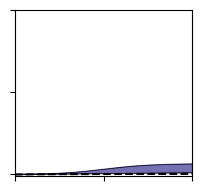

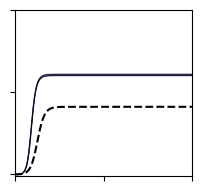

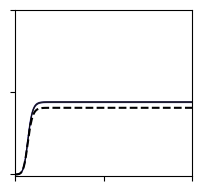

In [35]:
days = np.arange(0, simulated_days+1, 1)
colors_3 = ["#7570b3", "#d95f02", "#1b9e77"]

MINS_M, MAXS_M, BASES_M = calc_minmax_trajectories(SIRM, P_min_M, P_max_M, mus["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_M = plot_double_comparison(days, MINS_M, MAXS_M, BASES_M, "figures/Fig_3/comparison_M.pdf", Lx, Ly, color = colors_3[0])
avg_predicted = (MINS_M[-1] + MAXS_M[-1]) / 2
avg_base = (BASES_M[-1])
perc_increase = (avg_predicted - avg_base)  * 100
print(f"increase in infections for M model: + {perc_increase:.2f} %")




MINS_T, MAXS_T, BASES_T = calc_minmax_trajectories(SIRT, P_min_T, P_max_T, taus["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_T = plot_double_comparison(days, MINS_T, MAXS_T, BASES_T, "figures/Fig_3/comparison_T.pdf", Lx, Ly, color = colors_3[0])
avg_predicted = (MINS_T[-1] + MAXS_T[-1]) / 2
avg_base = (BASES_T[-1])
perc_increase = (avg_predicted - avg_base)  * 100
print(f"increase in infections for T model: + {perc_increase:.2f} %")



MINS_V, MAXS_V, BASES_V = calc_minmax_trajectories(SIRV, P_min_V, P_max_V, xis["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_V = plot_double_comparison(days, MINS_V, MAXS_V, BASES_V, "figures/Fig_3/comparison_V.pdf", Lx, Ly, color = colors_3[0])
avg_predicted = (MINS_V[-1] + MAXS_V[-1]) / 2
avg_base = (BASES_V[-1])
perc_increase = (avg_predicted - avg_base)  * 100
print(f"increase in infections for V model: + {perc_increase:.2f} %")





In [ ]:
days = np.arange(0, simulated_days+1, 1)
colors_3 = ["#7570b3", "#d95f02", "#1b9e77"]

MINS_M, MAXS_M, BASES_M = calc_minmax_trajectories(SIRM, P_min_M, P_max_M, mus["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_M = plot_double_comparison(days, MINS_M, MAXS_M, BASES_M, "figures/Fig_3/comparison_M.pdf", Lx, Ly, color = colors_3[0])
avg_predicted = (MINS_M[0][-1] + MAXS_M[0][-1]) / 2
avg_base = (BASES_M[0][-1])
perc_increase = (avg_predicted - avg_base)  * 100
print(f"increase in infections for T model: + {perc_increase:.2f} %")


MINS_T, MAXS_T, BASES_T = calc_minmax_trajectories(SIRT, P_min_T, P_max_T, taus["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_T = plot_double_comparison(days, MINS_T, MAXS_T, BASES_T, "figures/Fig_3/comparison_T.pdf", Lx, Ly, color = colors_3[1])
avg_predicted = (MINS_T[0][-1] + MINS_T[1][-1] + MAXS_T[0][-1] + MAXS_T[1][-1]) / 2
avg_base = (BASES_T[0][-1] + BASES_T[1][-1])
perc_increase = (avg_predicted - avg_base) * 100
print(f"increase in infections for T model: + {perc_increase:.2f}%")

MINS_V, MAXS_V, BASES_V = calc_minmax_trajectories(SIRV, P_min_V, P_max_V, xis["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_V = plot_double_comparison(days, MINS_V, MAXS_V, BASES_V, "figures/Fig_3/comparison_V.pdf", Lx, Ly, color = colors_3[2])
avg_predicted = (MINS_V[0][-1] + MINS_V[1][-1] + MAXS_V[0][-1] + MAXS_V[1][-1]) / 2
avg_base = (BASES_V[0][-1] + BASES_V[1][-1])
perc_increase = ((avg_predicted - avg_base)) * 100
print(f"Percentage increase in infections for V model: + {perc_increase:.2f}%")

# Things for Fig. 4:

In [22]:
R0s = np.round(np.linspace(1, 5, 30),2)
print(R0s)

[1.   1.14 1.28 1.41 1.55 1.69 1.83 1.97 2.1  2.24 2.38 2.52 2.66 2.79
 2.93 3.07 3.21 3.34 3.48 3.62 3.76 3.9  4.03 4.17 4.31 4.45 4.59 4.72
 4.86 5.  ]


In [ ]:
R0s = np.round(np.linspace(1, 5, 30), 2)

sirm_min_main = np.zeros(len(R0s))
sirm_max_main = np.zeros(len(R0s))
sirm_hom_main = np.zeros(len(R0s))

sirt_min_main = np.zeros(len(R0s))
sirt_max_main = np.zeros(len(R0s))
sirt_hom_main = np.zeros(len(R0s))

sirv_min_main = np.zeros(len(R0s))
sirv_max_main = np.zeros(len(R0s))
sirv_hom_main = np.zeros(len(R0s))
print(mus)
print(taus)
print(xis)
for i, R0 in enumerate(R0s):
    print(i, R0)
    if R0 == 2.52:
        flag_hist = True
    else:
        flag_hist = False
    het, hom, HeH, HoH = run_one(R0, PARAMS, mus, SIRM, [0.001], [0], simulated_days=simulated_days, sampling_points=2, flag = flag_hist)
    sirm_min_main[i] = np.min(np.array(het))
    sirm_max_main[i] = np.max(np.array(het))
    sirm_hom_main[i] = hom[0][0]
    if R0 == 2.52:
        het_hist_m = HeH
        hom_hist_m = HoH
        
    het, hom, HeH, HoH = run_one(R0, PARAMS, taus, SIRT, [0.001], [0], simulated_days=simulated_days, sampling_points=2, flag = flag_hist)
    sirt_min_main[i] = np.min(np.array(het))
    sirt_max_main[i] = np.max(np.array(het))
    sirt_hom_main[i] = hom[0][0]
    if R0 == 2.52:
        het_hist_t = HeH
        hom_hist_t = HoH

    het, hom, HeH, HoH = run_one(R0, PARAMS, xis, SIRV, [0.001], [0], simulated_days=simulated_days, sampling_points=2, flag = flag_hist)
    sirv_min_main[i] = np.min(np.array(het))
    sirv_max_main[i] = np.max(np.array(het))
    sirv_hom_main[i] = hom[0][0]
    if R0 == 2.52:
        het_hist_v = HeH
        hom_hist_v = HoH

{'mean': [0.76, 0.77, 0.79], 'pol': [0.25, 0.28, 0.3], 'h': [1.74, 2.58, 3.34]}
{'mean': [0.45, 0.47, 0.49], 'pol': [0.46, 0.48, 0.5], 'h': [1.97, 2.28, 2.58]}
{'mean': [0.59, 0.61, 0.63], 'pol': [0.55, 0.57, 0.6], 'h': [1.36, 1.72, 2.11]}
0 1.0
1 1.14
2 1.28
3 1.41
4 1.55
5 1.69
6 1.83
7 1.97
8 2.1
9 2.24
10 2.38
11 2.52
12 2.66
13 2.79
14 2.93
15 3.07
16 3.21
17 3.34
18 3.48
19 3.62
20 3.76
21 3.9
22 4.03
23 4.17
24 4.31
25 4.45
26 4.59
27 4.72
28 4.86
29 5.0


In [33]:
len(hom_hist_v[0][0][0][0])

5

In [ ]:
days = np.arange(0, simulated_days+1, 1)
colors_3 = ["#7570b3", "#d95f02", "#1b9e77"]

MINS_M, MAXS_M, BASES_M = calc_minmax_trajectories(SIRM, P_min_M, P_max_M, mus["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_M = plot_double_comparison(days, MINS_M, MAXS_M, BASES_M, "figures/Fig_3/comparison_M.pdf", Lx, Ly, color = colors_3[0])
avg_predicted = (MINS_M[-1] + MAXS_M[-1]) / 2
avg_base = (BASES_M[-1])
perc_increase = (avg_predicted - avg_base)  * 100
print(f"increase in infections for M model: + {perc_increase:.2f} %")




MINS_T, MAXS_T, BASES_T = calc_minmax_trajectories(SIRT, P_min_T, P_max_T, taus["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_T = plot_double_comparison(days, MINS_T, MAXS_T, BASES_T, "figures/Fig_3/comparison_T.pdf", Lx, Ly, color = colors_3[0])
avg_predicted = (MINS_T[-1] + MAXS_T[-1]) / 2
avg_base = (BASES_T[-1])
perc_increase = (avg_predicted - avg_base)  * 100
print(f"increase in infections for T model: + {perc_increase:.2f} %")



MINS_V, MAXS_V, BASES_V = calc_minmax_trajectories(SIRV, P_min_V, P_max_V, xis["mean"][1], PARAMS, default_0_pol, default_0_hom, simulated_days = simulated_days)
fig_comparison_V = plot_double_comparison(days, MINS_V, MAXS_V, BASES_V, "figures/Fig_3/comparison_V.pdf", Lx, Ly, color = colors_3[0])
avg_predicted = (MINS_V[-1] + MAXS_V[-1]) / 2
avg_base = (BASES_V[-1])
perc_increase = (avg_predicted - avg_base)  * 100
print(f"increase in infections for V model: + {perc_increase:.2f} %")




In [13]:
def calc_extra_infections(baseline, min_I, max_I):
    avg_inf_structure = 0.5*(min_I + max_I)*100
    return avg_inf_structure - baseline*100

def plot_3_lines(ax,R0s, baseline, min_I, max_I, color = "black"):
    ax.plot(R0s, min_I, color = color)
    ax.plot(R0s, max_I, color = color)
    ax.plot(R0s, baseline, "--", color = color)

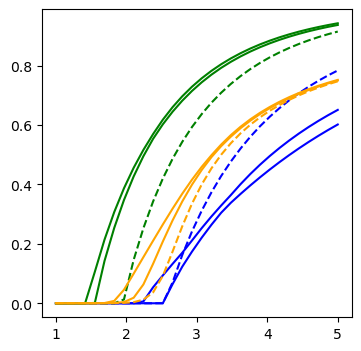

In [15]:
fig, axs = plt.subplots(1,1, figsize = (4,4))
plot_3_lines(axs, R0s, sirm_hom_main, sirm_min_main, sirm_max_main, color = "blue")
plot_3_lines(axs, R0s, sirt_hom_main, sirt_min_main, sirt_max_main, color = "green")
plot_3_lines(axs, R0s, sirv_hom_main, sirv_min_main, sirv_max_main, color = "orange")



array([2.51724138])

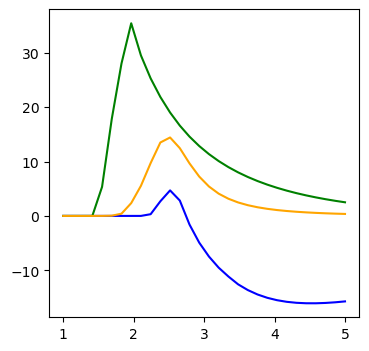

In [16]:
fig, axs = plt.subplots(1,1, figsize = (4,4))

axs.plot(R0s, calc_extra_infections(sirm_hom_main, sirm_min_main, sirm_max_main), color = "blue")
axs.plot(R0s, calc_extra_infections(sirt_hom_main, sirt_min_main, sirt_max_main), color = "green")
axs.plot(R0s, calc_extra_infections(sirv_hom_main, sirv_min_main, sirv_max_main), color = "orange")


V_EI = calc_extra_infections(sirv_hom_main, sirv_min_main, sirv_max_main)

R0s[V_EI == np.max(V_EI)]


In [ ]:
plot_three_extra_cases_ranges(
    [sirm_min_main, sirm_max_main, sirm_hom_main],
    [sirt_min_main, sirt_max_main, sirt_hom_main],
    [sirv_min_main, sirv_max_main, sirv_hom_main], R0s)

In [ ]:
plot_three_extra_cases_ranges(
    [sirm_min_main, sirm_max_main, sirm_hom_main],
    [sirt_min_main, sirt_max_main, sirt_hom_main],
    [sirv_min_main, sirv_max_main, sirv_hom_main], R0s) 

In [ ]:
plot_three_extra_cases_ranges(
    [sirm_min_main, sirm_max_main, sirm_hom_main],
    [sirt_min_main, sirt_max_main, sirt_hom_main],
    [sirv_min_main, sirv_max_main, sirv_hom_main], R0s) 